In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
xlims = [-100,100]
ylims = [-25,25]

fontsize=16
plt.rc('font', size=fontsize-4)

In [3]:
# From Sofi
def shortest_interval_68(data, center_type='mean'):
    """
    Compute the shortest interval that contains 68% of the data.
    """
    data = np.sort(data)
    n = len(data)
    ci_size = int(np.floor(0.68 * n))
    min_width = float("inf")
    min_i = 0

    for i in range(n - ci_size):
        width = data[i + ci_size] - data[i]
        if width < min_width:
            min_width = width
            min_i = i

    low = data[min_i]
    high = data[min_i + ci_size]

    if center_type == 'mean':
        center = np.mean(data)
    else:
        center = np.median(data)

    return {
        "center": center,
        "error_low": float(center - low),
        "error_high": float(high - center),
        "center_type": center_type
    }

In [4]:
colors = ['tab:blue']
vbl_names = {'x':r'$R_x$ [um]', 'y':r'$R_y$ [um]', 'A':r'$R_\alpha$ [deg]', 'B':r'$R_\beta$ [deg]'}

In [5]:
def residual_plot(ax, thisdf, var1, var2, name, lims=[-1,1]):
    
    nbins = 11 
    [xmin, xmax] = lims 
    step = 1.0*(xmax-xmin)/nbins

    bins = np.linspace(xmin,xmax,nbins)[:-1] + step/2
    
    ax.set_xlabel('True ' + name, fontsize=fontsize)
    ax.set_ylabel(vbl_names[var2], fontsize=fontsize)
    
    means = []
    up68 = []
    down68 = []
    upbar = []
    downbar = []
    
    for i in range(0,nbins-1):

        df_i = thisdf[(thisdf[var1]>xmin + i*step) & (thisdf[var1]<xmin + (i+1)*step)]
        
        means += [np.mean(df_i['residual'+var2])]
        interval68 =shortest_interval_68(df_i['residual'+var2], center_type='mean')
        up68 += [interval68['error_high']]
        down68 += [interval68['error_low']]
        upbar += [means[i] + np.mean(df_i['upsigma'+var2])]
        downbar += [means[i] - np.mean(df_i['downsigma'+var2])]

    ax.plot([xmin+step/2,xmax-step/2],[0,0],color='black',linestyle=':')
    if var2 == "x":
        ax.plot([xmin+step/2,xmax-step/2],[50/np.sqrt(12),50/np.sqrt(12)],color='black',linestyle=':')
        ax.plot([xmin+step/2,xmax-step/2],[-50/np.sqrt(12),-50/np.sqrt(12)],color='black',linestyle=':')
    if var2 == "y":
        ax.plot([xmin+step/2,xmax-step/2],[12.5/np.sqrt(12),12.5/np.sqrt(12)],color='black',linestyle=':')
        ax.plot([xmin+step/2,xmax-step/2],[-12.5/np.sqrt(12),-12.5/np.sqrt(12)],color='black',linestyle=':')
    
    #ax.errorbar(x=bins,y=means,yerr=[down68,up68],linestyle='',marker='o',markersize=3)
    line = ax.plot(bins,means,marker='o',markersize=3)
    ax.fill_between(x=bins,y1=upbar,y2=downbar, alpha=0.2)

    return line


/tmp/ipykernel_3102939/2387678301.py:5: UserWarning: The figure layout has changed to tight
  fig.tight_layout(pad=4.0)


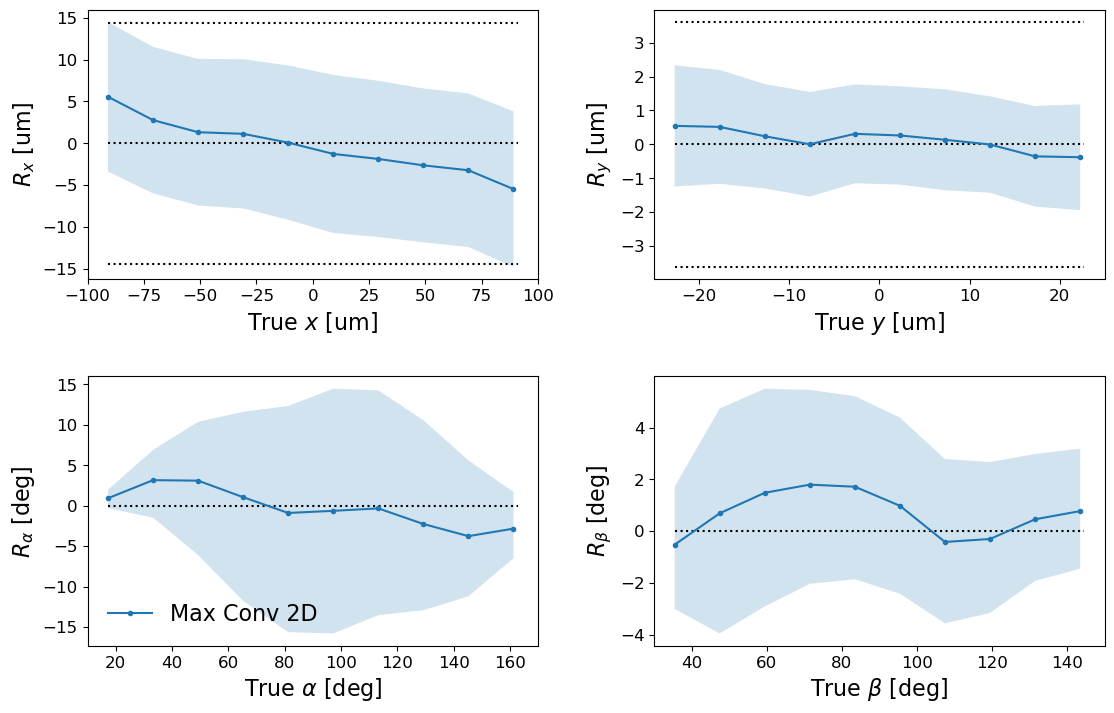

In [7]:
models = ["max_2dconv_2-noquant_2t"]
names = {"max_2dconv_2-noquant_2t":'Max Conv 2D'}

fig, axes = plt.subplots(2,2,figsize=(12,8),constrained_layout=True)
fig.tight_layout(pad=4.0)

lines = []
dump = []

for m in models:

    df = pd.read_parquet('dataset2s/predictions_'+m+'.parquet')

    for v in ['x','y']:
        df['upsigma'+v] = df['sigma'+v]
        df['downsigma'+v] = df['sigma'+v]

    lines += residual_plot(axes[0][0],df,'xtrue','x',r'$x$ [um]',lims = xlims)
    dump += residual_plot(axes[0][1],df,'ytrue','y',r'$y$ [um]',lims = ylims)
    dump += residual_plot(axes[1][0],df,'Atrue','A',r'$\alpha$ [deg]',lims=[10,170])
    dump += residual_plot(axes[1][1],df,'Btrue','B',r'$\beta$ [deg]',lims=[30,150])

axes[1][0].legend(lines,[names[m] for m in models], fontsize=fontsize, frameon=False, loc='lower left')

plt.savefig("dataset2s/plots/residuals_max.png")
plt.savefig("dataset2s/plots/residuals_max.pdf")


/tmp/ipykernel_3102939/905046234.py:9: UserWarning: The figure layout has changed to tight
  fig.tight_layout(pad=4.0)


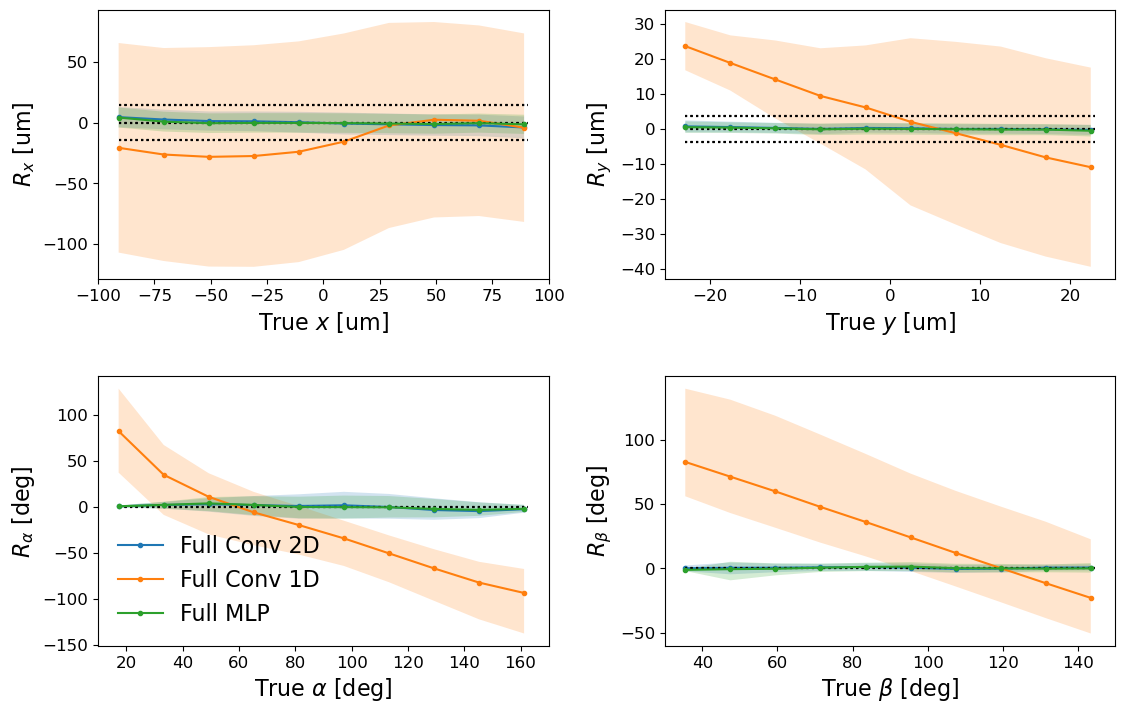

In [9]:
models = ["full_2dconv_2-noquant_2t",
          "full_1dconv_2-noquant_2t",
          "full_mlp_2-noquant_2t"]
names = {"full_2dconv_2-noquant_2t":'Full Conv 2D',
         "full_1dconv_2-noquant_2t":'Full Conv 1D',
         "full_mlp_2-noquant_2t":'Full MLP'}

fig, axes = plt.subplots(2,2,figsize=(12,8),constrained_layout=True)
fig.tight_layout(pad=4.0)

lines = []
dump = []

for m in models:

    df = pd.read_parquet('dataset2s/predictions_'+m+'.parquet')

    for v in ['x','y']:
        df['upsigma'+v] = df['sigma'+v]
        df['downsigma'+v] = df['sigma'+v]

    lines += residual_plot(axes[0][0],df,'xtrue','x',r'$x$ [um]',lims = xlims)
    dump += residual_plot(axes[0][1],df,'ytrue','y',r'$y$ [um]',lims = ylims)
    dump += residual_plot(axes[1][0],df,'Atrue','A',r'$\alpha$ [deg]',lims=[10,170])
    dump += residual_plot(axes[1][1],df,'Btrue','B',r'$\beta$ [deg]',lims=[30,150])

axes[1][0].legend(lines,[names[m] for m in models], fontsize=fontsize, frameon=False, loc='lower left')

plt.savefig("dataset2s/plots/residuals_full.png")
plt.savefig("dataset2s/plots/residuals_full.pdf")

In [10]:
def residual_plot_slim(ax, thisdf, var1, var2, name, lims=[-1,1]):

    print(np.max(thisdf[var1]),np.min(thisdf[var1]))
    
    nbins = 11 
    [xmin, xmax] = lims 
    step = 1.0*(xmax-xmin)/nbins

    bins = np.linspace(xmin,xmax,nbins)[:-1] + step/2
    
    ax.set_xlabel('True ' + name, fontsize=fontsize)
    ax.set_ylabel(vbl_names[var2], fontsize=fontsize)
    
    means = []
    up68 = []
    down68 = []
    upbar = []
    downbar = []
    
    for i in range(0,nbins-1):

        df_i = thisdf[(thisdf[var1]>xmin + i*step) & (thisdf[var1]<xmin + (i+1)*step)]
        
        means += [np.mean(df_i['residual'+var2])]
        interval68 =shortest_interval_68(df_i['residual'+var2], center_type='mean')
        up68 += [interval68['error_high']]
        down68 += [interval68['error_low']]

    ax.plot([xmin+step/2,xmax-step/2],[0,0],color='black',linestyle=':')
    if var2 == "x":
        ax.plot([xmin+step/2,xmax-step/2],[50/np.sqrt(12),50/np.sqrt(12)],color='black',linestyle=':')
        ax.plot([xmin+step/2,xmax-step/2],[-50/np.sqrt(12),-50/np.sqrt(12)],color='black',linestyle=':')
    if var2 == "y":
        ax.plot([xmin+step/2,xmax-step/2],[12.5/np.sqrt(12),12.5/np.sqrt(12)],color='black',linestyle=':')
        ax.plot([xmin+step/2,xmax-step/2],[-12.5/np.sqrt(12),-12.5/np.sqrt(12)],color='black',linestyle=':')
        
    line = ax.errorbar(x=bins,y=means,yerr=[down68,up68],marker='o',markersize=3,capsize=2)
    #line = ax.plot(bins,means,marker='o',markersize=3)
    #ax.fill_between(x=bins,y1=upbar,y2=downbar, alpha=0.2)

    return [line]


/tmp/ipykernel_3102939/2794114104.py:9: UserWarning: The figure layout has changed to tight
  fig.tight_layout(pad=4.0)


100.161575 -100.09663
25.089386 -25.053658
167.00838 13.071061
100.161575 -100.09663
25.089386 -25.053658
167.00838 13.071061
100.47951 -100.287384
25.03165 -25.019014
140.05289 40.125214
[<ErrorbarContainer object of 3 artists>, <ErrorbarContainer object of 3 artists>, <ErrorbarContainer object of 3 artists>]


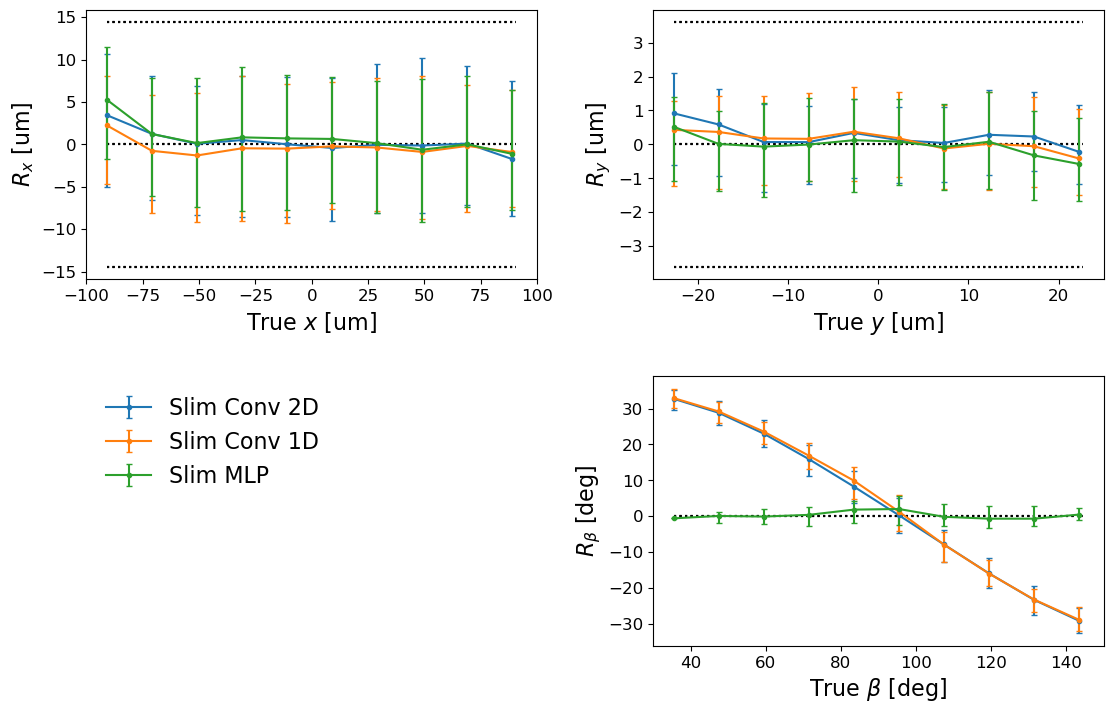

In [11]:
models = ["slim_2dconv_2-noquant_2t",
          "slim_1dconv_2-noquant_2t",
          "slim_mlp_2-noquant_2t"]
names = {"slim_2dconv_2-noquant_2t":'Slim Conv 2D',
         "slim_1dconv_2-noquant_2t":'Slim Conv 1D',
         "slim_mlp_2-noquant_2t":'Slim MLP'}

fig, axes = plt.subplots(2,2,figsize=(12,8),constrained_layout=True)
fig.tight_layout(pad=4.0)

axes[1,0].axis('off')

lines = []
dump = []

for m in models:

    df = pd.read_parquet('dataset2s/predictions_'+m+'.parquet')
    
    lines += residual_plot_slim(axes[0][0],df,'xtrue','x',r'$x$ [um]',lims = xlims)
    dump += residual_plot_slim(axes[0][1],df,'ytrue','y',r'$y$ [um]',lims = ylims)
    dump += residual_plot_slim(axes[1][1],df,'Btrue','B',r'$\beta$ [deg]',lims=[30,150])

print(lines)

axes[1][0].legend(lines,[names[m] for m in models], fontsize=fontsize, frameon=False, loc='upper left')

plt.savefig("dataset2s/plots/residuals_slim.png")
plt.savefig("dataset2s/plots/residuals_slim.pdf")

/tmp/ipykernel_3102939/2787352091.py:9: UserWarning: The figure layout has changed to tight
  fig.tight_layout(pad=4.0)


100.161575 -100.09663
25.089386 -25.053658
167.00838 13.071061


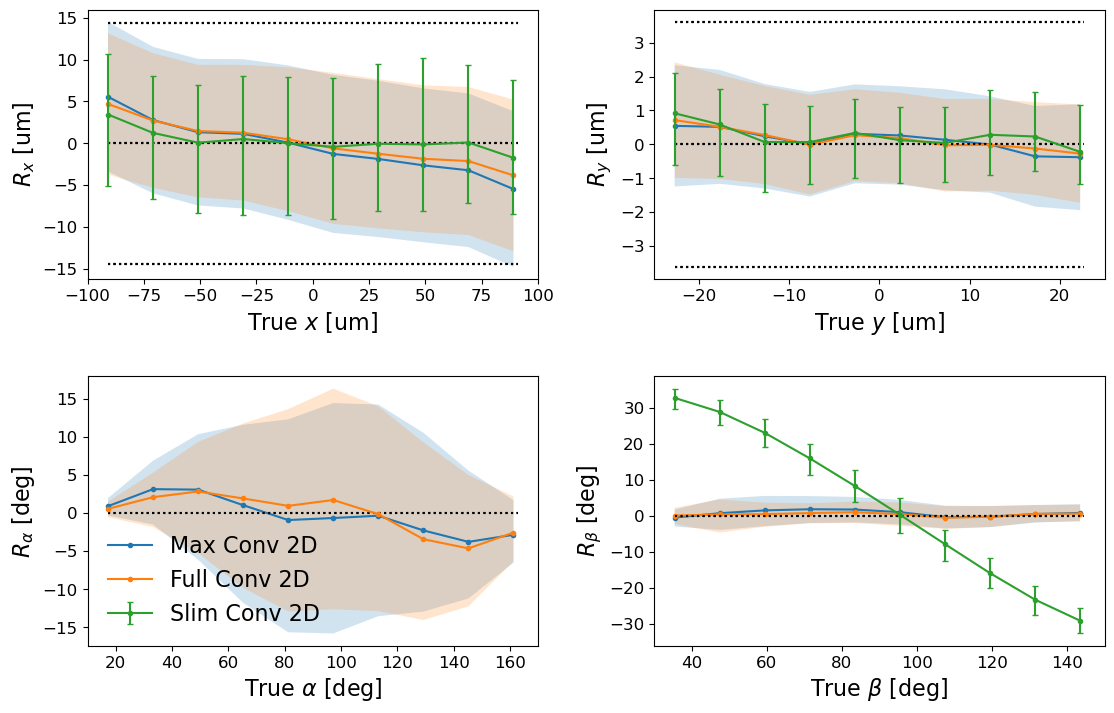

In [15]:
models = ["max_2dconv_2-noquant_2t",
          "full_2dconv_2-noquant_2t",
          "slim_2dconv_2-noquant_2t"]
names = {"max_2dconv_2-noquant_2t":'Max Conv 2D',
         "full_2dconv_2-noquant_2t":'Full Conv 2D',
         "slim_2dconv_2-noquant_2t":'Slim Conv 2D'}

fig, axes = plt.subplots(2,2,figsize=(12,8),constrained_layout=True)
fig.tight_layout(pad=4.0)

lines = []
dump = []

for m in models:

    df = pd.read_parquet('dataset2s/predictions_'+m+'.parquet')

    if "slim" not in m:

        for v in ['x','y']:
            df['upsigma'+v] = df['sigma'+v]
            df['downsigma'+v] = df['sigma'+v]
            
        lines += residual_plot(axes[0][0],df,'xtrue','x',r'$x$ [um]',lims = xlims)
        dump += residual_plot(axes[0][1],df,'ytrue','y',r'$y$ [um]',lims = ylims)
        dump += residual_plot(axes[1][0],df,'Atrue','A',r'$\alpha$ [deg]',lims=[10,170])
        dump += residual_plot(axes[1][1],df,'Btrue','B',r'$\beta$ [deg]',lims=[30,150])
    else:
        lines += residual_plot_slim(axes[0][0],df,'xtrue','x',r'$x$ [um]',lims = xlims)
        dump += residual_plot_slim(axes[0][1],df,'ytrue','y',r'$y$ [um]',lims = ylims)
        dump += residual_plot_slim(axes[1][1],df,'Btrue','B',r'$\beta$ [deg]',lims=[30,150])

axes[1][0].legend(lines,[names[m] for m in models], fontsize=fontsize, frameon=False, loc='lower left')

plt.savefig("dataset2s/plots/residuals_2dconv.png")
plt.savefig("dataset2s/plots/residuals_2dconv.pdf")

/tmp/ipykernel_3102939/2478515605.py:7: UserWarning: The figure layout has changed to tight
  fig.tight_layout(pad=4.0)


100.161575 -100.09663
25.089386 -25.053658
167.00838 13.071061
[<matplotlib.lines.Line2D object at 0x7fab1ae78ce0>, <ErrorbarContainer object of 3 artists>]


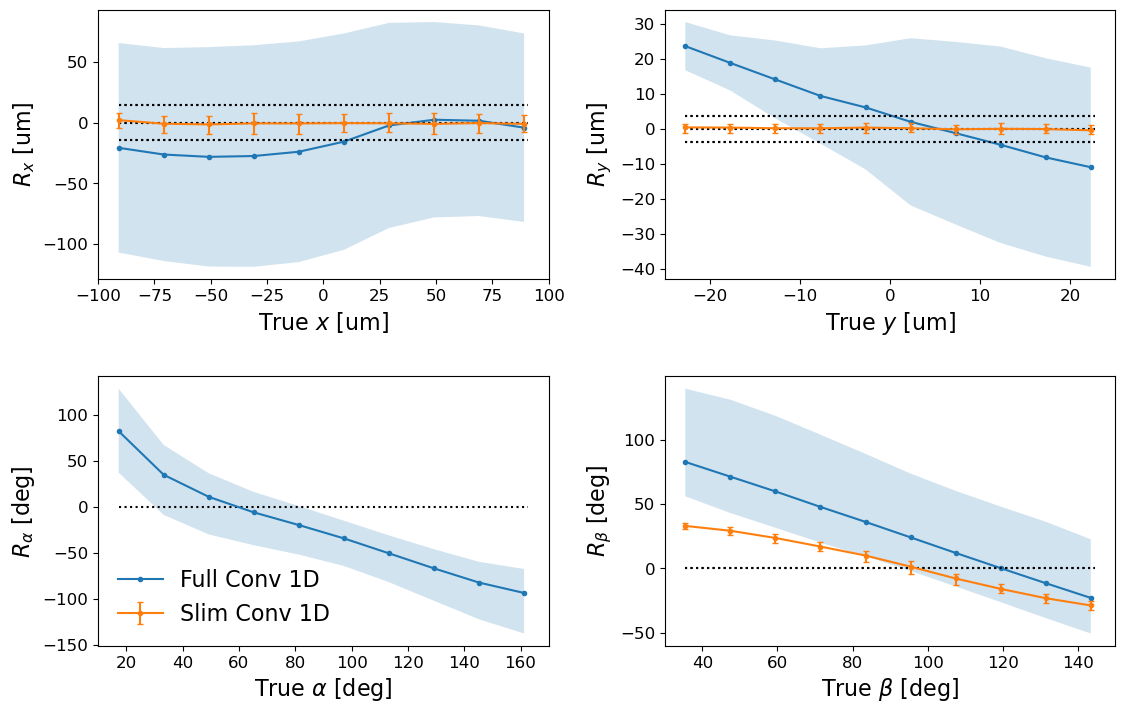

In [18]:
models = ["full_1dconv_2-noquant_2t",
          "slim_1dconv_2-noquant_2t"]
names = {"full_1dconv_2-noquant_2t":'Full Conv 1D',
         "slim_1dconv_2-noquant_2t":'Slim Conv 1D'}

fig, axes = plt.subplots(2,2,figsize=(12,8),constrained_layout=True)
fig.tight_layout(pad=4.0)

lines = []
dump = []

for m in models:

    df = pd.read_parquet('dataset2s/predictions_'+m+'.parquet')

    if "slim" not in m:

        for v in ['x','y']:
            df['upsigma'+v] = df['sigma'+v]
            df['downsigma'+v] = df['sigma'+v]
            
        lines += residual_plot(axes[0][0],df,'xtrue','x',r'$x$ [um]',lims = xlims)
        dump += residual_plot(axes[0][1],df,'ytrue','y',r'$y$ [um]',lims = ylims)
        dump += residual_plot(axes[1][0],df,'Atrue','A',r'$\alpha$ [deg]',lims=[10,170])
        dump += residual_plot(axes[1][1],df,'Btrue','B',r'$\beta$ [deg]',lims=[30,150])
    else:
        lines += residual_plot_slim(axes[0][0],df,'xtrue','x',r'$x$ [um]',lims = xlims)
        dump += residual_plot_slim(axes[0][1],df,'ytrue','y',r'$y$ [um]',lims = ylims)
        dump += residual_plot_slim(axes[1][1],df,'Btrue','B',r'$\beta$ [deg]',lims=[30,150])

print(lines)
axes[1][0].legend(lines,[names[m] for m in models], fontsize=fontsize, frameon=False, loc='lower left')

plt.savefig("plots/residuals_1dconv.png")
plt.savefig("plots/residuals_1dconv.pdf")

/tmp/ipykernel_3102939/929220370.py:7: UserWarning: The figure layout has changed to tight
  fig.tight_layout(pad=4.0)


100.47951 -100.287384
25.03165 -25.019014
140.05289 40.125214
[<matplotlib.lines.Line2D object at 0x7fab30358470>, <ErrorbarContainer object of 3 artists>]


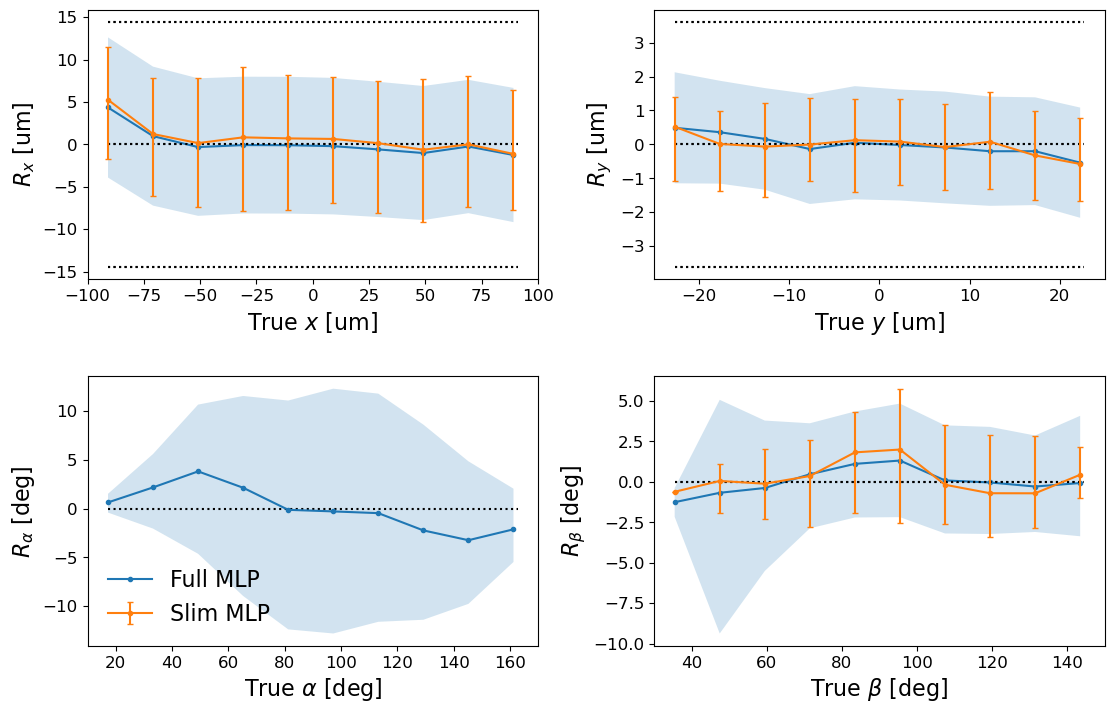

In [19]:
models = ["full_mlp_2-noquant_2t",
          "slim_mlp_2-noquant_2t"]
names = {"full_mlp_2-noquant_2t":'Full MLP',
         "slim_mlp_2-noquant_2t":'Slim MLP'}

fig, axes = plt.subplots(2,2,figsize=(12,8),constrained_layout=True)
fig.tight_layout(pad=4.0)

lines = []
dump = []

for m in models:

    df = pd.read_parquet('dataset2s/predictions_'+m+'.parquet')

    if "slim" not in m:

        for v in ['x','y']:
            df['upsigma'+v] = df['sigma'+v]
            df['downsigma'+v] = df['sigma'+v]
            
        lines += residual_plot(axes[0][0],df,'xtrue','x',r'$x$ [um]',lims = xlims)
        dump += residual_plot(axes[0][1],df,'ytrue','y',r'$y$ [um]',lims = ylims)
        dump += residual_plot(axes[1][0],df,'Atrue','A',r'$\alpha$ [deg]',lims=[10,170])
        dump += residual_plot(axes[1][1],df,'Btrue','B',r'$\beta$ [deg]',lims=[30,150])
    else:
        lines += residual_plot_slim(axes[0][0],df,'xtrue','x',r'$x$ [um]',lims = xlims)
        dump += residual_plot_slim(axes[0][1],df,'ytrue','y',r'$y$ [um]',lims = ylims)
        dump += residual_plot_slim(axes[1][1],df,'Btrue','B',r'$\beta$ [deg]',lims=[30,150])

print(lines)
axes[1][0].legend(lines,[names[m] for m in models], fontsize=fontsize, frameon=False, loc='lower left')

plt.savefig("plots/residuals_mlp.png")
plt.savefig("plots/residuals_mlp.pdf")

/tmp/ipykernel_3102939/2098772167.py:5: UserWarning: The figure layout has changed to tight
  fig.tight_layout(pad=4.0)


100.47951 -100.287384
25.03165 -25.019014
140.05289 40.125214


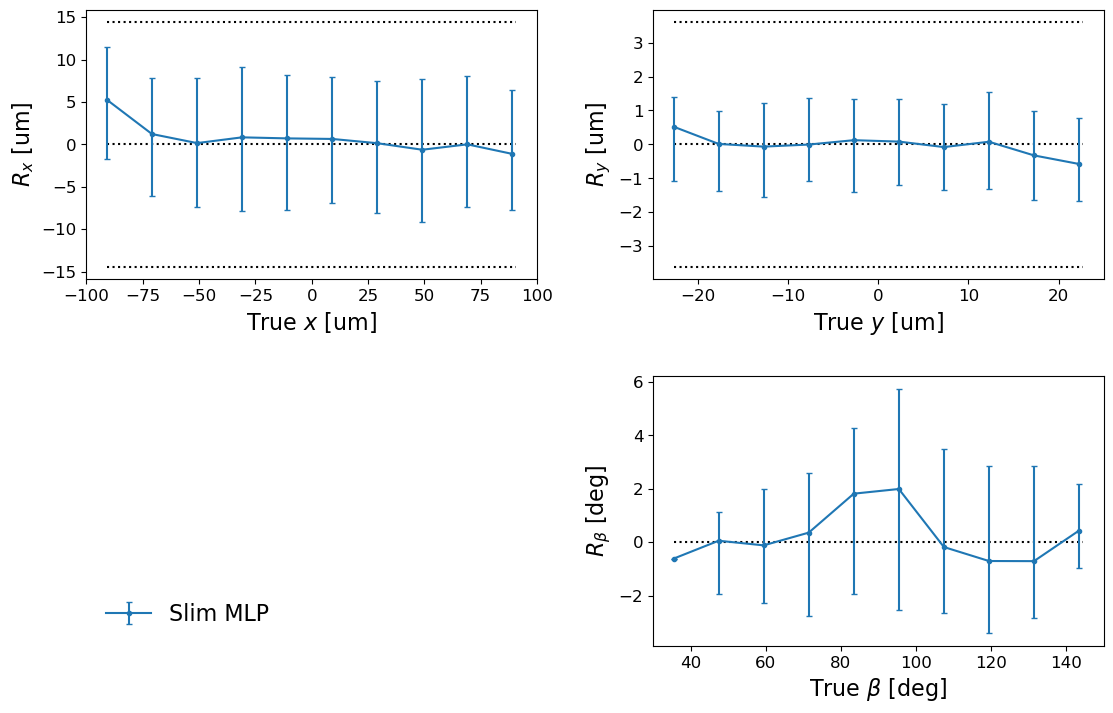

In [20]:
models = ["slim_mlp_2-noquant_2t"]
names = {"slim_mlp_2-noquant_2t":'Slim MLP'}

fig, axes = plt.subplots(2,2,figsize=(12,8),constrained_layout=True)
fig.tight_layout(pad=4.0)
axes[1,0].axis('off')

lines = []
dump = []

for m in models:

    df = pd.read_parquet('dataset2s/predictions_'+m+'.parquet')

    lines += residual_plot_slim(axes[0][0],df,'xtrue','x',r'$x$ [um]',lims = xlims)
    dump += residual_plot_slim(axes[0][1],df,'ytrue','y',r'$y$ [um]',lims = ylims)
    dump += residual_plot_slim(axes[1][1],df,'Btrue','B',r'$\beta$ [deg]',lims=[30,150])

axes[1][0].legend(lines,[names[m] for m in models], fontsize=fontsize,frameon=False, loc='lower left')

#plt.savefig("plots/residuals_max.png")
#plt.savefig("plots/residuals_max.pdf")